In [1]:
import pandas as pd

df = pd.read_csv("Datos_evidencia2.csv")


df_limpio = df.dropna()

df_limpio["Fecha"] = pd.to_datetime(df_limpio["Fecha"], errors="coerce")

print(df_limpio)

     Sucursal      Fecha  Ingresos  Gastos
0   Sucursal1 2023-01-01     12000    8500
1   Sucursal2 2023-01-01     15000   13000
2   Sucursal3 2023-01-01     10000    7500
3   Sucursal4 2023-01-01      9000    6000
4   Sucursal1 2023-01-08     13000    9000
..        ...        ...       ...     ...
83  Sucursal4 2023-05-21     29000   26000
84  Sucursal1 2023-05-28     33000   28000
85  Sucursal2 2023-05-28     36000   34000
86  Sucursal3 2023-05-28     31000   27000
87  Sucursal4 2023-05-28     30000   27000

[88 rows x 4 columns]


In [3]:
df_limpio["Ganancia_Neta"] = df_limpio["Ingresos"] - df_limpio["Gastos"]

df_limpio["Margen_Rentabilidad"] = (df_limpio["Ganancia_Neta"] / df_limpio["Ingresos"]) * 100

print(df_limpio)

     Sucursal      Fecha  Ingresos  Gastos  Ganancia_Neta  Margen_Rentabilidad
0   Sucursal1 2023-01-01     12000    8500           3500            29.166667
1   Sucursal2 2023-01-01     15000   13000           2000            13.333333
2   Sucursal3 2023-01-01     10000    7500           2500            25.000000
3   Sucursal4 2023-01-01      9000    6000           3000            33.333333
4   Sucursal1 2023-01-08     13000    9000           4000            30.769231
..        ...        ...       ...     ...            ...                  ...
83  Sucursal4 2023-05-21     29000   26000           3000            10.344828
84  Sucursal1 2023-05-28     33000   28000           5000            15.151515
85  Sucursal2 2023-05-28     36000   34000           2000             5.555556
86  Sucursal3 2023-05-28     31000   27000           4000            12.903226
87  Sucursal4 2023-05-28     30000   27000           3000            10.000000

[88 rows x 6 columns]


In [5]:
df_agrupado = df_limpio.groupby("Sucursal").agg({
    "Ingresos": "sum",
    "Gastos": "sum",
}).reset_index()

df_agrupado["Ganancia_Neta"] = df_agrupado["Ingresos"] - df_agrupado["Gastos"]

df_agrupado["Margen_Rentabilidad"] = (df_agrupado["Ganancia_Neta"] / df_agrupado["Ingresos"]) * 100

print(df_agrupado)

    Sucursal  Ingresos  Gastos  Ganancia_Neta  Margen_Rentabilidad
0  Sucursal1    495000  388000         107000            21.616162
1  Sucursal2    561000  517000          44000             7.843137
2  Sucursal3    451000  367500          83500            18.514412
3  Sucursal4    429000  363000          66000            15.384615


In [24]:
std_ganancia = df_limpio.groupby('Sucursal')['Ganancia_Neta'].std()
cv_ganancia = std_ganancia / df_limpio.groupby('Sucursal')['Ganancia_Neta'].mean()

print(std_ganancia)
print(cv_ganancia)


Sucursal
Sucursal1    383.648468
Sucursal2      0.000000
Sucursal3    479.560585
Sucursal4      0.000000
Name: Ganancia_Neta, dtype: float64
Sucursal
Sucursal1    0.078881
Sucursal2    0.000000
Sucursal3    0.126351
Sucursal4    0.000000
Name: Ganancia_Neta, dtype: float64


In [27]:
sucursal2 = df_limpio[df_limpio["Sucursal"] == "Sucursal2"]
print(sucursal2)

sucursal4 = df_limpio[df_limpio["Sucursal"] == "Sucursal4"]

print(sucursal4)

     Sucursal      Fecha  Ingresos  Gastos  Ganancia_Neta  Margen_Rentabilidad
1   Sucursal2 2023-01-01     15000   13000           2000            13.333333
5   Sucursal2 2023-01-08     16000   14000           2000            12.500000
9   Sucursal2 2023-01-15     17000   15000           2000            11.764706
13  Sucursal2 2023-01-22     18000   16000           2000            11.111111
17  Sucursal2 2023-01-29     19000   17000           2000            10.526316
21  Sucursal2 2023-02-05     20000   18000           2000            10.000000
25  Sucursal2 2023-02-12     21000   19000           2000             9.523810
29  Sucursal2 2023-02-19     22000   20000           2000             9.090909
33  Sucursal2 2023-02-26     23000   21000           2000             8.695652
37  Sucursal2 2023-03-05     24000   22000           2000             8.333333
41  Sucursal2 2023-03-12     25000   23000           2000             8.000000
45  Sucursal2 2023-03-19     26000   24000          

         Ingresos  Gastos
Mes                      
2023-01    270000  207500
2023-02    288000  232000
2023-03    352000  296000
2023-04    530000  460000
2023-05    496000  440000


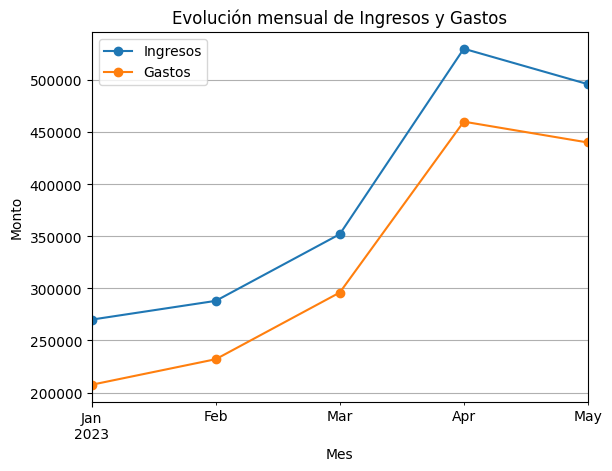

         Ingresos  Gastos  Ganancia     Margen
Mes                                           
2023-01    270000  207500     62500  23.148148
2023-02    288000  232000     56000  19.444444
2023-03    352000  296000     56000  15.909091
2023-04    530000  460000     70000  13.207547
2023-05    496000  440000     56000  11.290323


In [30]:
df_limpio['Fecha'] = pd.to_datetime(df_limpio['Fecha'])

df_limpio['Mes'] = df_limpio['Fecha'].dt.to_period('M')


tendencia = df_limpio.groupby('Mes')[['Ingresos', 'Gastos']].sum()

print(tendencia)

import matplotlib.pyplot as plt

tendencia.plot(kind='line', marker='o')
plt.title("Evolución mensual de Ingresos y Gastos")
plt.ylabel("Monto")
plt.xlabel("Mes")
plt.grid()
plt.show()



tendencia['Ganancia'] = tendencia['Ingresos'] - tendencia['Gastos']
tendencia['Margen'] = (tendencia['Ganancia'] / tendencia['Ingresos']) * 100

print(tendencia.sort_values(by='Margen', ascending=False))

In [46]:
semanas = df_limpio.set_index('Fecha').resample('W').agg({
    'Ingresos': 'sum',
    'Gastos': 'sum',
})
semanas['Ganancia'] = semanas['Ingresos'] - semanas['Gastos']
semanas['Margen_Rentabilidad'] = (semanas['Ganancia'] / semanas['Ingresos']) * 100

filtrado = semanas[semanas['Margen_Rentabilidad'] > semanas['Margen_Rentabilidad'].mean()]
top5 = semanas.sort_values(by='Margen_Rentabilidad', ascending=False).head(5)
print(top5)


            Ingresos  Gastos  Ganancia  Margen_Rentabilidad
Fecha                                                      
2023-01-01     46000   35000     11000            23.913043
2023-01-22     58000   44500     13500            23.275862
2023-01-15     54000   41500     12500            23.148148
2023-01-08     50000   38500     11500            23.000000
2023-01-29     62000   48000     14000            22.580645


In [47]:
alertas = df_limpio[
    (df_limpio['Margen_Rentabilidad'] < df_limpio['Margen_Rentabilidad'].mean()) |
    (df_limpio['Gastos'] > df_limpio['Ingresos'] * 0.8)
]


print(alertas)


alertas.to_excel("reporte_alertas.xlsx", index=False)

     Sucursal      Fecha  Ingresos  Gastos  Ganancia_Neta  \
1   Sucursal2 2023-01-01     15000   13000           2000   
5   Sucursal2 2023-01-08     16000   14000           2000   
9   Sucursal2 2023-01-15     17000   15000           2000   
13  Sucursal2 2023-01-22     18000   16000           2000   
17  Sucursal2 2023-01-29     19000   17000           2000   
21  Sucursal2 2023-02-05     20000   18000           2000   
25  Sucursal2 2023-02-12     21000   19000           2000   
29  Sucursal2 2023-02-19     22000   20000           2000   
31  Sucursal4 2023-02-19     16000   13000           3000   
33  Sucursal2 2023-02-26     23000   21000           2000   
35  Sucursal4 2023-02-26     17000   14000           3000   
37  Sucursal2 2023-03-05     24000   22000           2000   
39  Sucursal4 2023-03-05     18000   15000           3000   
41  Sucursal2 2023-03-12     25000   23000           2000   
43  Sucursal4 2023-03-12     19000   16000           3000   
45  Sucursal2 2023-03-19